In [2]:
!pip install --upgrade numpy scipy scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


--- Loaded Environment Versions ---
NumPy Version:        1.26.4
Pandas Version:       2.3.3
Scikit-Learn Version: 1.7.2

[1/4] Loading CSV files from /home/mtech/S5_csea_09/exp7/archive...
[2/4] Standardizing pixel features...
[3/4] Training SVM kernels and computing performance metrics...

--> Training Linear SVM...
--> Training Polynomial SVM (d=3)...
--> Training RBF SVM (Gaussian)...

EXPERIMENT 12: SVM KERNEL COMPARISON SUMMARY
              Kernel  Accuracy (%)  Precision  Recall  F1-Score  Train Time (s)  Pred Time (s)
          Linear SVM         81.85     0.8183  0.8185    0.8168            6.41           3.99
Polynomial SVM (d=3)         83.60     0.8469  0.8360    0.8389            8.88           2.80
  RBF SVM (Gaussian)         85.30     0.8520  0.8530    0.8516            7.45           3.53

[4/4] Plotting comparison graphs...


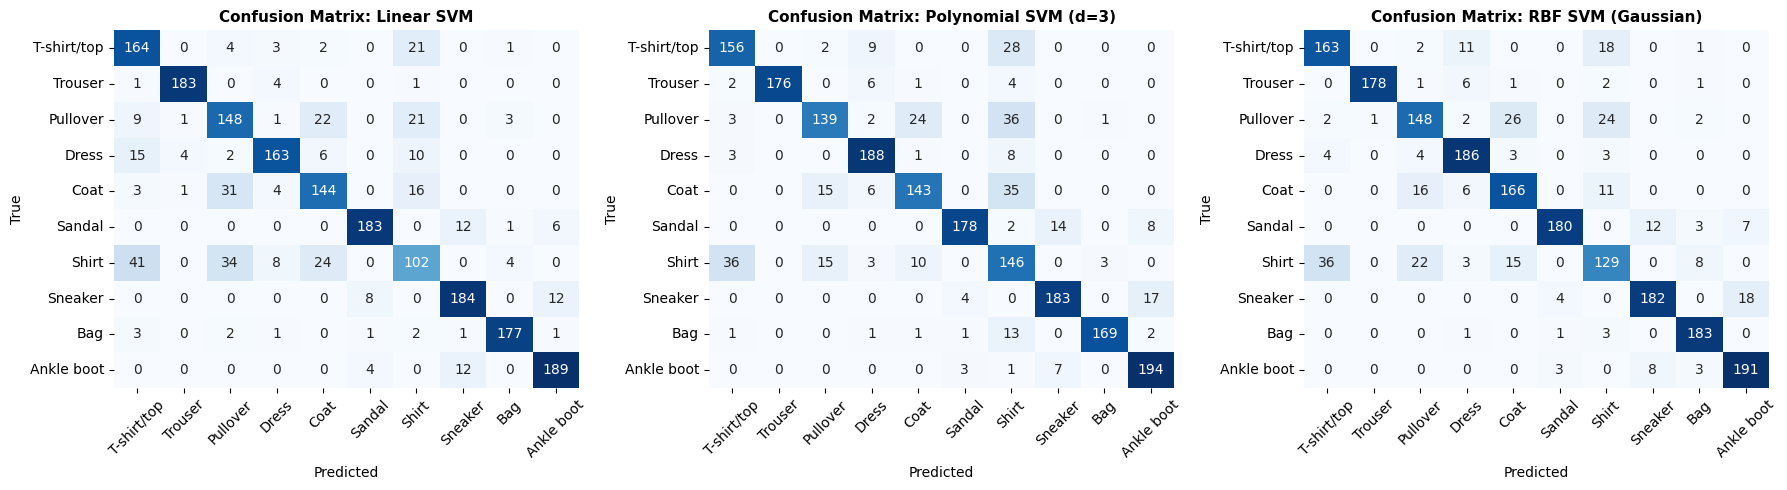

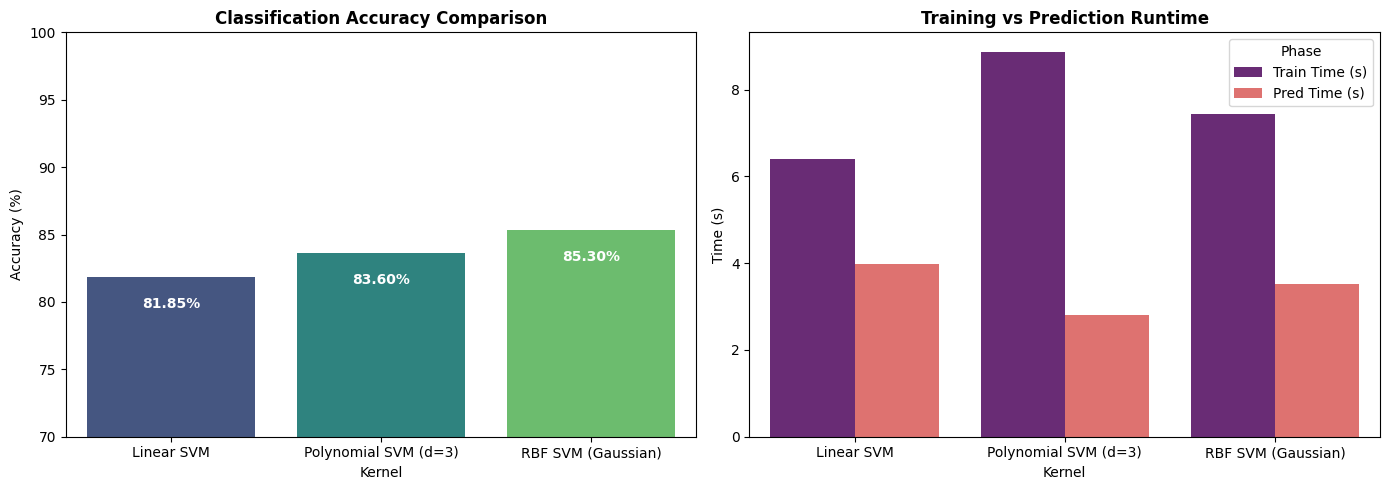

In [8]:
import os
import time
import warnings

# Mute NumPy/SciPy version mismatch and convergence warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

# -------------------------------------------------------------------------
# 1. Environment & Environment Version Verification
# -------------------------------------------------------------------------
print("--- Loaded Environment Versions ---")
print(f"NumPy Version:        {np.__version__}")
print(f"Pandas Version:       {pd.__version__}")
print(f"Scikit-Learn Version: {sklearn.__version__}\n")

# -------------------------------------------------------------------------
# 2. File Paths & Parameters
# -------------------------------------------------------------------------
DATA_DIR = "/home/mtech/S5_csea_09/exp7/archive"
TRAIN_PATH = os.path.join(DATA_DIR, "fashion-mnist_train.csv")
TEST_PATH = os.path.join(DATA_DIR, "fashion-mnist_test.csv")

CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

TRAIN_SIZE = 10000  # Subsample size for manageable SVM training time O(n^2)
TEST_SIZE = 2000
RANDOM_STATE = 42

# -------------------------------------------------------------------------
# 3. Data Loading and Preprocessing
# -------------------------------------------------------------------------
print(f"[1/4] Loading CSV files from {DATA_DIR}...")
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

# Extract features and targets
X_train_raw = train_df.drop(columns=['label']).values[:TRAIN_SIZE]
y_train = train_df['label'].values[:TRAIN_SIZE]

X_test_raw = test_df.drop(columns=['label']).values[:TEST_SIZE]
y_test = test_df['label'].values[:TEST_SIZE]

# Standardize pixel values (Mean = 0, Variance = 1)
print("[2/4] Standardizing pixel features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw)

# -------------------------------------------------------------------------
# 4. Model Configurations & Execution
# -------------------------------------------------------------------------
kernels = {
    'Linear SVM': SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE),
    'Polynomial SVM (d=3)': SVC(kernel='poly', degree=3, C=1.0, random_state=RANDOM_STATE),
    'RBF SVM (Gaussian)': SVC(kernel='rbf', gamma='scale', C=1.0, random_state=RANDOM_STATE)
}

print("[3/4] Training SVM kernels and computing performance metrics...\n")
summary_records = []
confusion_mats = {}

for name, model in kernels.items():
    print(f"--> Training {name}...")
    
    # Measure Training Time
    t_start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - t_start
    
    # Predict and Measure Time
    t_start = time.time()
    y_pred = model.predict(X_test_scaled)
    pred_time = time.time() - t_start
    
    # Compute Metrics
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
    
    summary_records.append({
        'Kernel': name,
        'Accuracy (%)': round(acc * 100, 2),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Train Time (s)': round(train_time, 2),
        'Pred Time (s)': round(pred_time, 2)
    })
    
    confusion_mats[name] = confusion_matrix(y_test, y_pred)

# -------------------------------------------------------------------------
# 5. Output Summary Table & Plots
# -------------------------------------------------------------------------
print("\n" + "="*80)
print("EXPERIMENT 12: SVM KERNEL COMPARISON SUMMARY")
print("="*80)
df_summary = pd.DataFrame(summary_records)
print(df_summary.to_string(index=False))

print("\n[4/4] Plotting comparison graphs...")

# Plot 1: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, cm) in zip(axes, confusion_mats.items()):
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False
    )
    ax.set_title(f"Confusion Matrix: {name}", fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Plot 2: Accuracy vs Execution Latency
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Bar Plot
sns.barplot(data=df_summary, x='Kernel', y='Accuracy (%)', ax=axes[0], palette='viridis')
axes[0].set_title("Classification Accuracy Comparison", fontsize=12, fontweight='bold')
axes[0].set_ylim(70, 100)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.2f}%", 
                     (p.get_x() + p.get_width() / 2., p.get_height() - 2),
                     ha='center', va='center', color='white', fontweight='bold')

# Execution Time Plot
df_time = df_summary.melt(id_vars=['Kernel'], value_vars=['Train Time (s)', 'Pred Time (s)'],
                           var_name='Phase', value_name='Time (s)')
sns.barplot(data=df_time, x='Kernel', y='Time (s)', hue='Phase', ax=axes[1], palette='magma')
axes[1].set_title("Training vs Prediction Runtime", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()